# Requirements

## 1. Conda environment setup

A dedicated Conda environment should be created to install the Copernicus Marine Service toolbox and the associated scientific Python libraries. This environment is intended for data download, preliminary inspection, and basic visualization of the retrieved datasets.

An example Conda environment definition file, `cmems.yaml`, is provided below.

---

```yaml
name: cmems
channels:
  - conda-forge
dependencies:
  - python=3.11
  - copernicusmarine
  - xarray
  - netcdf4
  - h5netcdf
  - cftime
  - numpy
  - pandas
  - dask
  - scipy
  - matplotlib
  - cartopy
  - tqdm
  - pyyaml
  - ipython
  - ipykernel
  - ipywidgets
  - bottleneck
```

---

The environment can then be created using:

```bash
conda env create -f cmems.yml
```

---

## 2. Environment activation and Jupyter configuration

After installation, the environment should be activated and registered as a Jupyter kernel to ensure that all subsequent notebook-based workflows use the correct Python environment.

---

## 3. Copernicus Marine authentication

To enable authenticated access to the Copernicus Marine Service, user credentials should be configured once at the system level. This can be achieved by executing the login command in a terminal session, which generates a local credential file. This file allows repeated data access without re-entering authentication details for each download request.

```bash
conda activate cmems
copernicusmarine login
```

# Import Module

In [1]:
# Copernicu Marine Service module to access and download the data
import copernicusmarine

# Modules to check and visualise the data
import xarray as xr
from matplotlib.colors import LogNorm

# Downloading options

## Subset of dataset 

the `subset` function is able to download a subset of the dataset defined by several factors, as longitude, latitude, datetimes, depth and etc. The dataset is directly downloaded in the mentioned output_diretory.

In [ ]:
dataset_id = "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"

copernicusmarine.subset(
  dataset_id = dataset_id,
  variables = ["CHL"],
  minimum_longitude = 50,
  maximum_longitude = 90,
  minimum_latitude = 0,
  maximum_latitude = 25,
  start_datetime = "2022-01-01T00:00:00",
  end_datetime = "2022-01-01T23:59:59",
  output_filename = "Chla.nc",
  output_directory = f"data/{dataset_id}/"
)

In [ ]:
# Loading and visualising the downloaded dataset
ds = xr.open_dataset(f"data/{dataset_id}/PFT.nc")
ds.CHL.plot(norm=LogNorm(0.01,10))

## Extract and show the metadata of dataset before downloading

The `open_dataset` function only extract and show the metadata of the file, the file could then be downloaded using `persist()`, `load()` or simply saving the file using `to_netcdf()` or `to_zarr()`. The dataset would also be downloaded and visualised directly using the `plot` function.

In [ ]:
dataset_id = "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"
ds = copernicusmarine.open_dataset(
    dataset_id = dataset_id,
    minimum_longitude = -30, 
    maximum_longitude = -20,
    minimum_latitude = 30,
    maximum_latitude = 40,
    start_datetime = "2022-01-01T00:00:00",    
    end_datetime = "2022-01-31T23:59:59", 
    variables = ["CHL"], 
)

INFO - 2026-02-03T21:30:46Z - Selected dataset version: "202411"
INFO - 2026-02-03T21:30:46Z - Selected dataset part: "default"


In [ ]:
ds1 = ds.CHL.sel(time='2022-01-15').load()
ds2 = ds.CHL.sel(time='2022-01-15').persist()
ds.CHL.sel(time='2022-01-15').to_netcdf(f'data/{dataset_id}/CHL.nc')

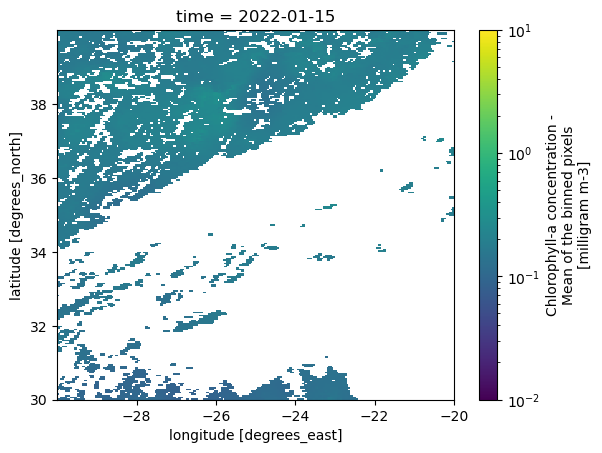

In [ ]:
## Download and visualise one day of data

ds.CHL.sel(time='2022-01-15').plot(norm=LogNorm(0.01,10))

## Download the whole scene dataset (e.g. global)

A full scene (e.g., in case of global dataset a full daily global dataset) can be downloaded directly, without any subsetting, if the dataset are not downloadable via the pervisously mentioned methods. In this situation the name and data of desired data would be scanned using regular experessions (`regex`). A guideline for using regex are provided in the following image and link.

[https://docs.python.org/3/library/re.html](https://docs.python.org/3/library/re.html)

<img src="https://miro.medium.com/v2/resize:fit:1400/1*hjsbL45MhT2Tw5DGAYoAUg.png" style="width: 500px;"/>

In [ ]:
# Define parameters to run the extraction
dataset_id = "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"

# Define output storage parameters
output_directory = "./data/PFT_global/"

date_range = "*2022010[0-1]*"

# Call the get function to save data
get_result_annualmean = copernicusmarine.get(
    dataset_id=dataset_id,
    filter = date_range,
    output_directory=output_directory,
    no_directories=True)

INFO - 2026-02-03T21:24:29Z - Selected dataset version: "202411"
INFO - 2026-02-03T21:24:29Z - Selected dataset part: "default"
INFO - 2026-02-03T21:24:30Z - Listing files on remote server...
11it [00:03,  3.02it/s]


---

# Downloading Phytoplankton functional types (PFT) for our study region

## subset

In [ ]:
copernicusmarine.subset(
    dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l3-olci-4km_P1D",
    variables=["CHL"],
    minimum_longitude = -50, 
    maximum_longitude = -20,
    minimum_latitude = 0,
    # maximum_latitude = 30,
    start_datetime="2022-01-01T00:00:00",
    end_datetime="2022-01-10T23:59:59",
    output_filename = "CHL.nc",
    output_directory = "./copernicus-data/CHL_4km"
)

## open_dataset

In [ ]:
ds = copernicusmarine.open_dataset(
    dataset_id="cmems_obs-oc_glo_bgc-plankton_my_l3-olci-4km_P1D",
    variables=["CHL"],
    minimum_longitude = -50, 
    maximum_longitude = -20,
    minimum_latitude = 0,
    # maximum_latitude = 30,
    start_datetime="2022-01-01T00:00:00",
    end_datetime="2022-01-10T23:59:59",
)

In [ ]:
ds.isel(time=5).CHL.plot(robust=True, norm=LogNorm())

# PFT YEARLY

In [ ]:
# Define parameters to run the extraction
dataset_id_yearly = "cmems_obs-oc_glo_bgc-plankton_my_l3-multi-4km_P1D"

# Define output storage parameters
output_directory = "/albedo/work/projects/p_phytooptics/emehdipo/PS113/CMEMS/data"

date_range = "*20190[1-5]*"

# Call the get function to save data
get_result_annualmean = copernicusmarine.get(
    dataset_id=dataset_id_yearly,
    filter = date_range,
    output_directory=output_directory,
    no_directories=True)

In [ ]:
dataset_id = "METOFFICE-GLO-SST-L4-NRT-OBS-SST-V2"

copernicusmarine.subset(
  dataset_id=dataset_id,
  variables=["analysed_sst", "analysis_error"],
  minimum_longitude=-64,
  maximum_longitude=3,
  minimum_latitude=-50,
  maximum_latitude=52,
  start_datetime="2016-01-01T00:00:00",
  end_datetime="2019-12-31T23:59:59",
  output_filename = f"{dataset_id}_2016_2019.nc",
  output_directory = "/albedo/work/projects/p_phytooptics/emehdipo/PS113/GHRSST/"
)